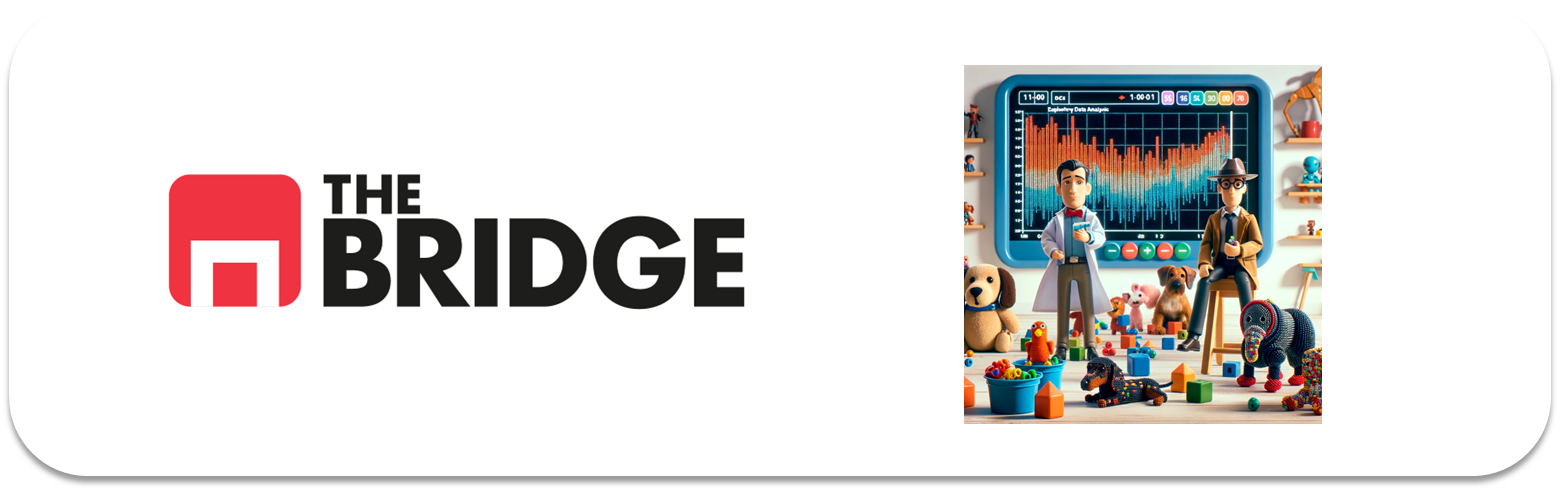

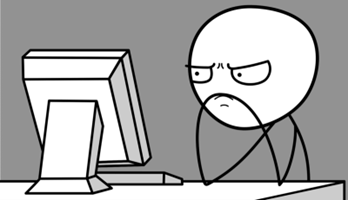

Para ejercitarte y afianzar lo aprendido sobre el análisis bivariante, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)
  
La solución a los mismos se subirá a lo largo del sprint.

### Ejercicio 0


Importa los paquetes y módulos que necesites a lo largo del notebook

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

### Ejercicio 1

Carga el dataset de admisiones que conoces de la unidad anterior y que se encuentra en la ruta "./data/admission_data.csv", deshazte de las columnas innecesarias

In [3]:
df = pd.read_csv("./data/admission_data.csv")
df

,Unnamed: 0,Year,Major,Gender,Admission
0,0,1973,School of Medicine,F,Rejected
1,1,1973,Department of Economics,M,Accepted
2,2,1973,Other,F,Accepted
3,3,1973,Other,M,Accepted
4,4,1973,Other,M,Rejected
...,...,...,...,...,...
12758,12758,1973,Other,M,Accepted
12759,12759,1973,Department of Mechanical Engineering,M,Accepted
12760,12760,1973,Other,F,Rejected
12761,12761,1973,Other,M,Rejected


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12763 entries, 0 to 12762
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Unnamed: 0  12763 non-null  int64
 1   Year        12763 non-null  int64
 2   Major       12763 non-null  str  
 3   Gender      12763 non-null  str  
 4   Admission   12763 non-null  str  
dtypes: int64(2), str(3)
memory usage: 498.7 KB


In [5]:
# cardinalidad para clasificar el tipo de variables
def cardinalidad(df_in, umbral_categoria, umbral_continua):
    
    resultados = []

    for col in df_in.columns:
        # Cardinalidad absoluta
        card = df_in[col].nunique(dropna=True)
        
        # Porcentaje de cardinalidad
        pct = card / len(df_in) * 100
        
        # Clasificación según reglas
        if card == 2:
            tipo = "Binaria"
        
        elif card < umbral_categoria:
            tipo = "Categórica"
        
        else:
            # card >= umbral_categoria → mirar porcentaje
            if pct >= umbral_continua:
                tipo = "Numerica Continua"
            else:
                tipo = "Numerica Discreta"
        
        resultados.append({
            "columna": col,
            "cardinalidad": card,
            "pct_cardinalidad": pct,
            "clasificacion": tipo
        })
    
    return pd.DataFrame(resultados)

In [6]:
cardinalidad(df, 10, 0.3)

,columna,cardinalidad,pct_cardinalidad,clasificacion
0,Unnamed: 0,12763,100.000000,Numerica Continua
1,Year,1,0.007835,Categórica
2,Major,7,0.054846,Categórica
3,Gender,2,0.015670,Binaria
4,Admission,2,0.015670,Binaria


In [7]:
df.Year.value_counts()
df = df.drop(columns=["Year"])



In [15]:
df

,Unnamed: 0,Major,Gender,Admission
0,0,School of Medicine,F,Rejected
1,1,Department of Economics,M,Accepted
2,2,Other,F,Accepted
3,3,Other,M,Accepted
4,4,Other,M,Rejected
...,...,...,...,...
12758,12758,Other,M,Accepted
12759,12759,Department of Mechanical Engineering,M,Accepted
12760,12760,Other,F,Rejected
12761,12761,Other,M,Rejected


In [8]:
df.set_index("Unnamed: 0")

,Major,Gender,Admission
Unnamed: 0,,,
0,School of Medicine,F,Rejected
1,Department of Economics,M,Accepted
2,Other,F,Accepted
3,Other,M,Accepted
4,Other,M,Rejected
...,...,...,...
12758,Other,M,Accepted
12759,Department of Mechanical Engineering,M,Accepted
12760,Other,F,Rejected


### Ejercicio 2

Haz el análisis bivariante de "Admission" y "Major" (emplea las funciones del workout importándolas del módulo `bootcampviztools`, o utiliza las visualizaciones del notebook en el repositorio) y contesta a las siguientes preguntas:
* ¿Cuál es el departamento con el mayor porcentaje de admsiones?¿Y el de menor?
    - El departamento con e mayor porcentaje de admisiones es "Department of Psychology"
    - El menor es "Department of Physics and Astronomy"
* ¿Existe alguna diferencia destacada entre los departamentos?
    - Podemos ver que todos los departamentos tienen mayor porcentajes de aceptados que negados, excepto en Economicas y Astronomia

In [9]:
from bootcampviztools import plot_categorical_numerical_relationship, plot_combined_graphs, \
    pinta_distribucion_categoricas, plot_grouped_boxplots, grafico_dispersion_con_correlacion, plot_categorical_relationship_fin

In [10]:
df["Major"].unique()

<StringArray>
[                                     'School of Medicine',
                                 'Department of Economics',
                                                   'Other',
                                'Department of Psychology',
                     'Department of Physics and Astronomy',
                    'Department of Mechanical Engineering',
 'School of Political Science and International Relations']
Length: 7, dtype: str

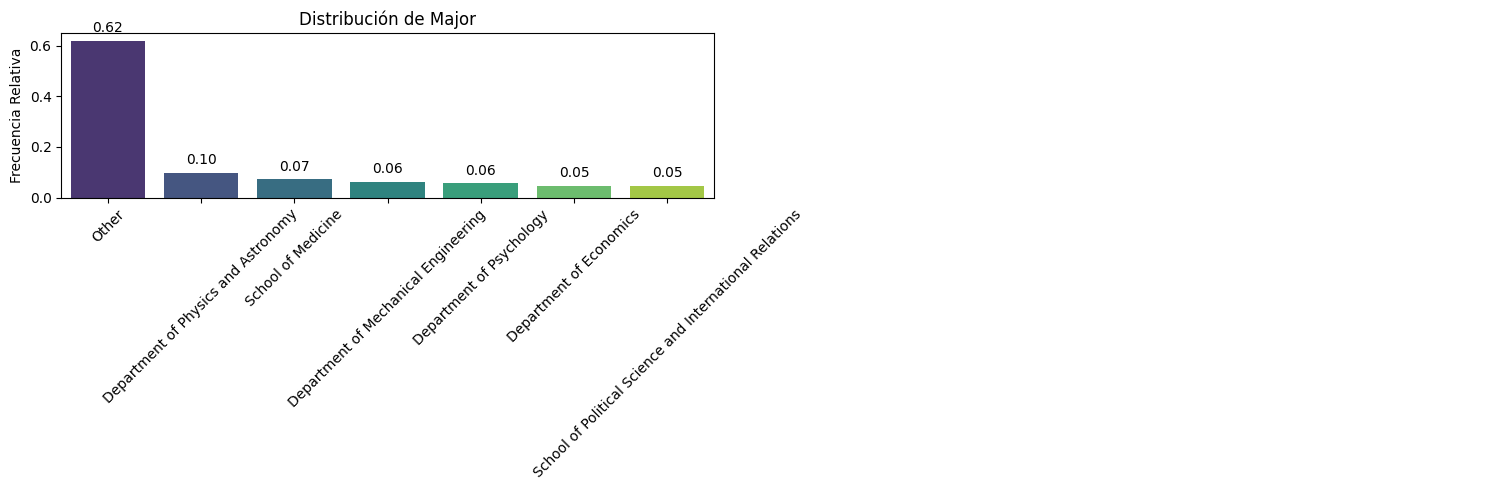

In [11]:
# Admission variable categórica binaria
# Major variable categórica
# primero analizamos por separado
pinta_distribucion_categoricas(df,["Major"], relativa= True, mostrar_valores= True)


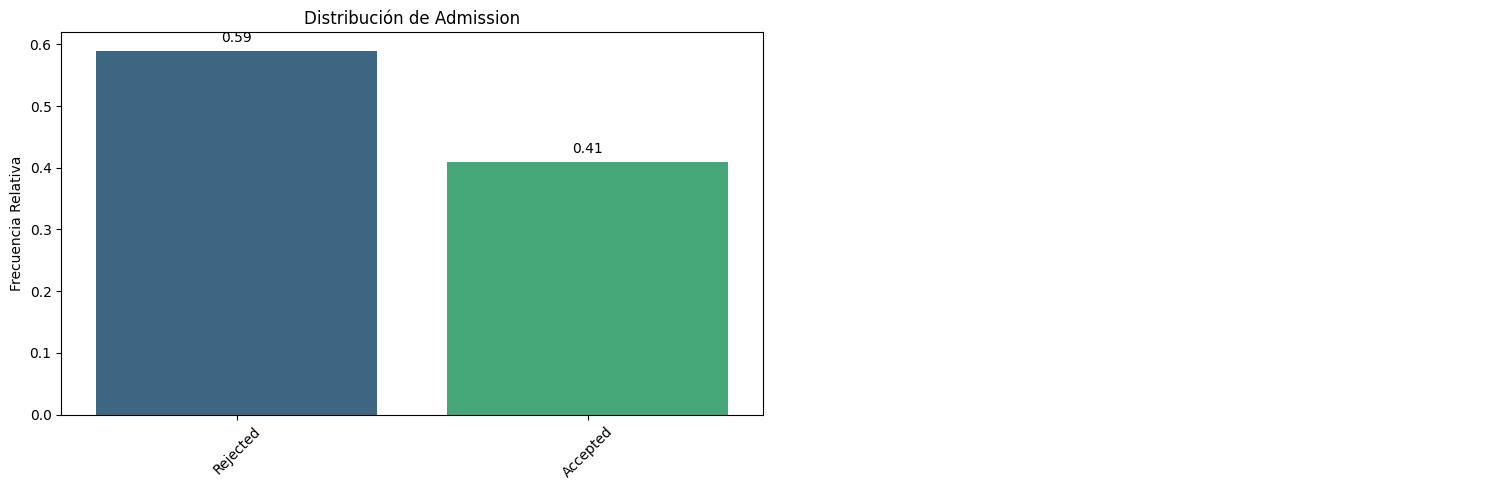

In [12]:
pinta_distribucion_categoricas(df,["Admission"], relativa= True, mostrar_valores= True)

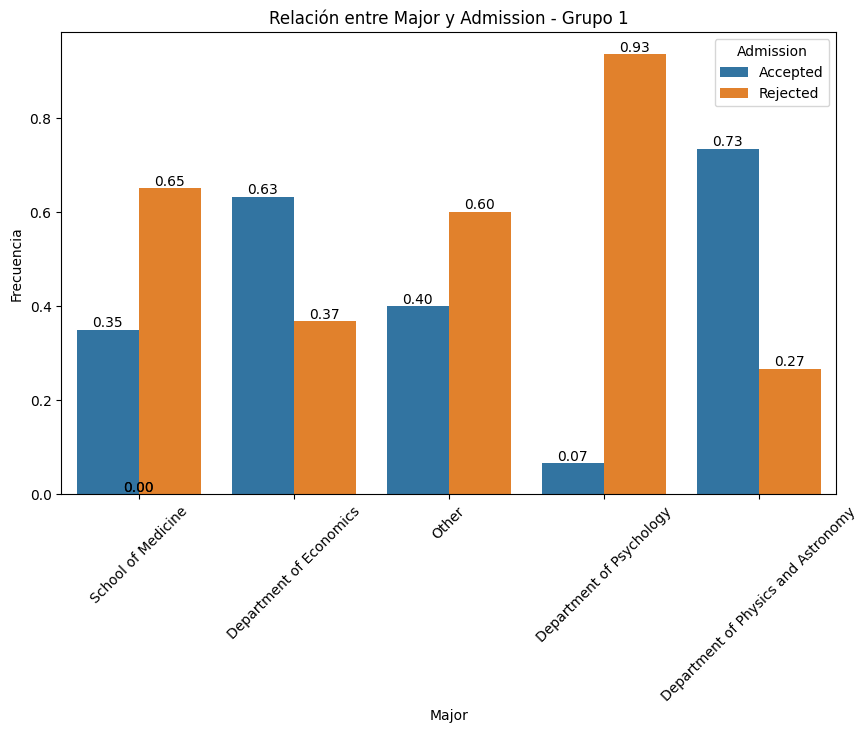

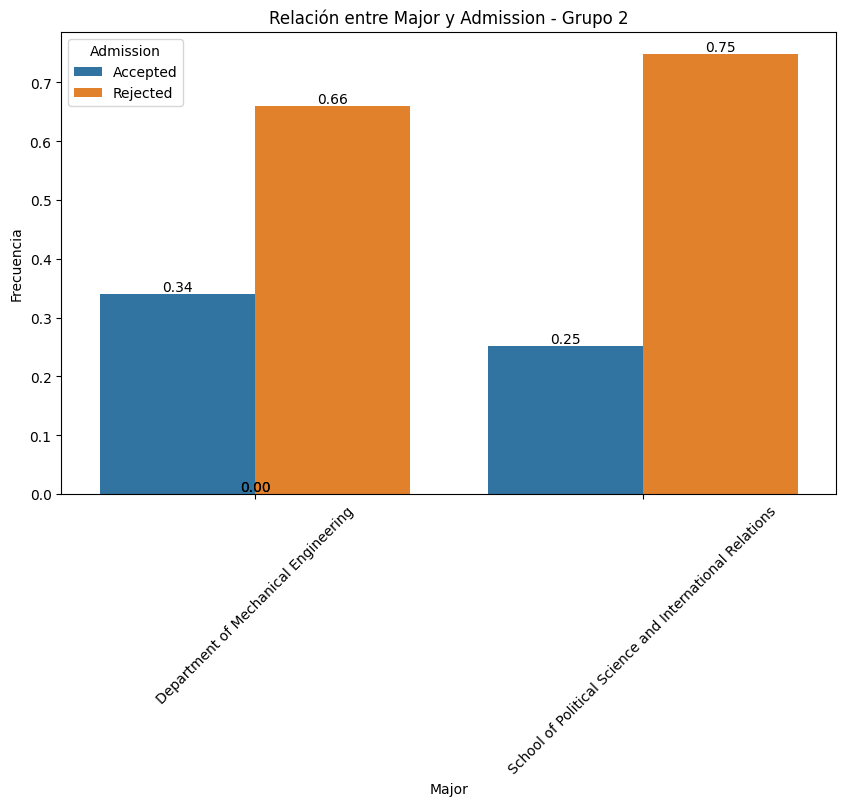

In [30]:
plot_categorical_relationship_fin(df, "Major","Admission", relative_freq = True, show_values = True)

### Ejercicio 3

Repite el análisis para "Admission" y "Gender" y responde a las siguientes preguntas:
* ¿Existe una diferencia visual significativa entre el porcentaje de admitidos de cada género?
    - En el genero femenino hay mayor diferencia de porcentaje de acetados y no
    - En el genero masculino es casi un 50%
* ¿Cuál de los dos grupos tiene más admisiones?
    - Femenino

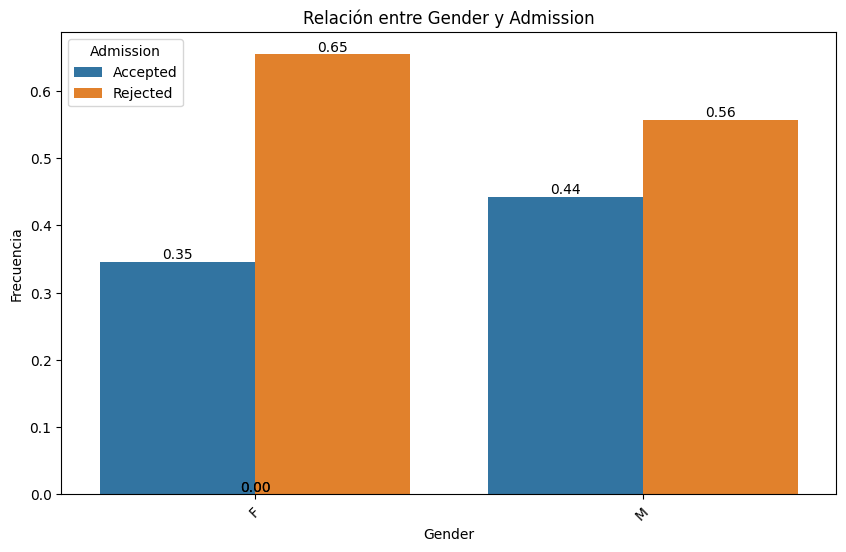

In [13]:
plot_categorical_relationship_fin(df, "Gender","Admission", relative_freq = True, show_values = True)

### Ejercicio 4

Carga el dataset de propinas (tips) que conoces de la unidad anterior y que se encuentra en la ruta "./data/tips.csv", deshazte de las columnas innecesarias

In [14]:
df_tips = pd.read_csv("./data/tips.csv")
df_tips

,Unnamed: 0,total_bill,tip,sex,smoker,day,time,size
0,0,16.99,1.01,Female,No,Sun,Dinner,2
1,1,10.34,1.66,Male,No,Sun,Dinner,3
2,2,21.01,3.50,Male,No,Sun,Dinner,3
3,3,23.68,3.31,Male,No,Sun,Dinner,2
4,4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...,...
239,239,29.03,5.92,Male,No,Sat,Dinner,3
240,240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,242,17.82,1.75,Male,No,Sat,Dinner,2


In [15]:
df_tips.set_index("Unnamed: 0")

,total_bill,tip,sex,smoker,day,time,size
Unnamed: 0,,,,,,,
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2


In [16]:
cardinalidad(df_tips, 10, 0.3)

,columna,cardinalidad,pct_cardinalidad,clasificacion
0,Unnamed: 0,244,100.000000,Numerica Continua
1,total_bill,229,93.852459,Numerica Continua
2,tip,123,50.409836,Numerica Continua
3,sex,2,0.819672,Binaria
4,smoker,2,0.819672,Binaria
5,day,4,1.639344,Categórica
6,time,2,0.819672,Binaria
7,size,6,2.459016,Categórica


### Ejercicio 5

Haz el análisis bivariante de "tip" y "sex" (emplea las funciones del workout importándolas del módulo `bootcampviztools`, o utiliza las visualizaciones del notebook en el repositorio), añade el cálculo de la media y mediana de la variable continua por cada valor de la variable categórica, y contesta a las siguientes preguntas:
* ¿Existe alguna diferencia visualmente significativa entre las propinas de los grupos de la variable "sex"?
* ¿Son diferentes respecto al  conjunto total?

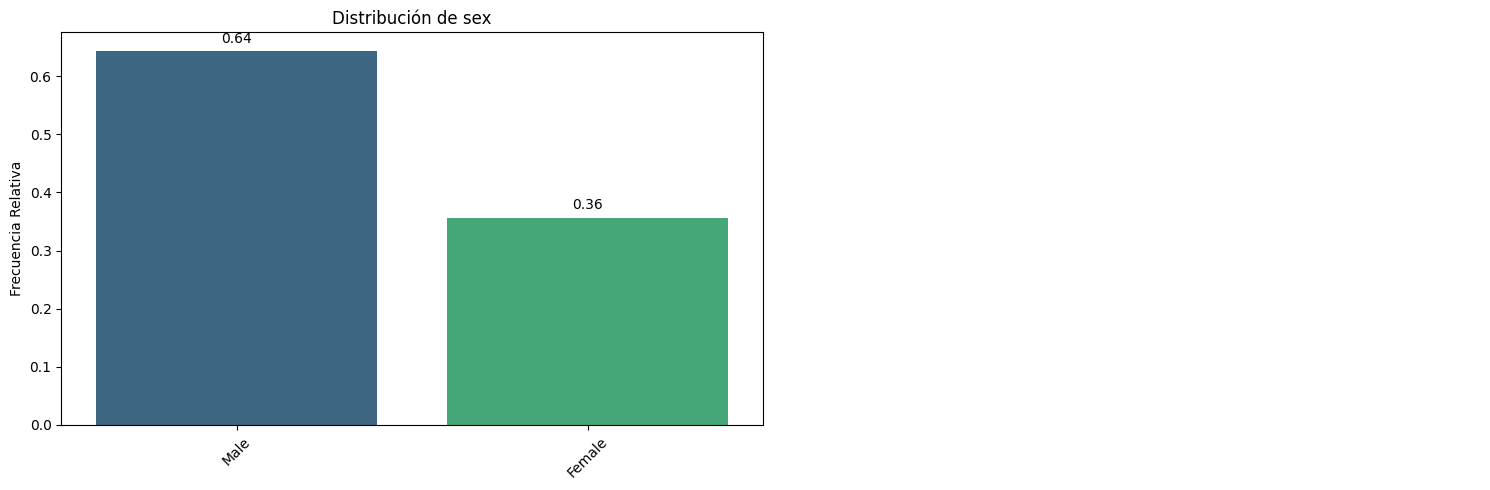

In [17]:
pinta_distribucion_categoricas(df_tips,["sex"], relativa= True, mostrar_valores= True)

(2,)


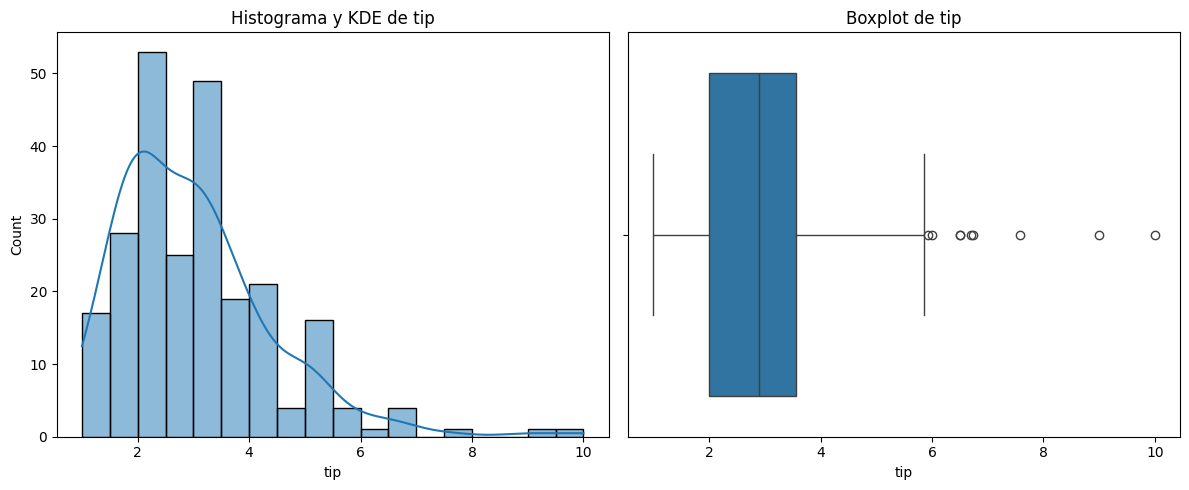

In [18]:
plot_combined_graphs(df_tips,["tip"])

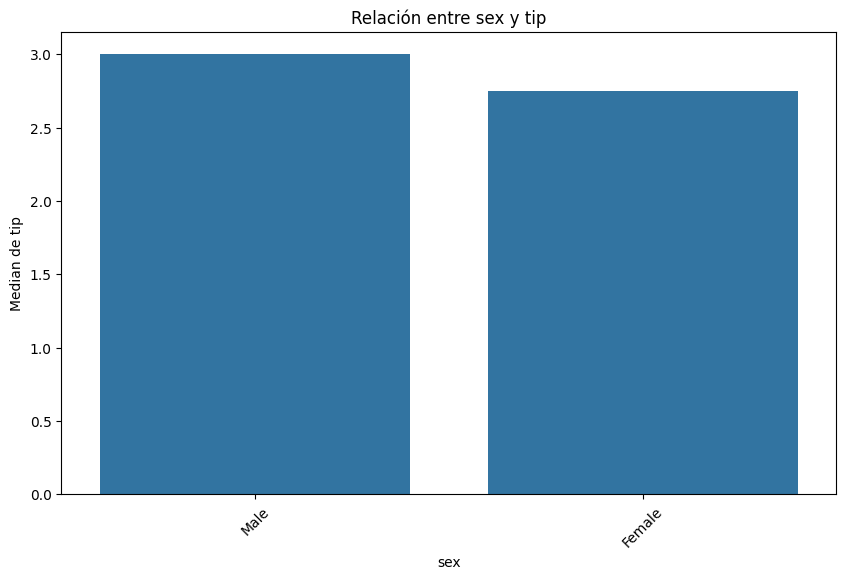

In [19]:
plot_categorical_numerical_relationship(df_tips,"sex","tip", measure = "median")

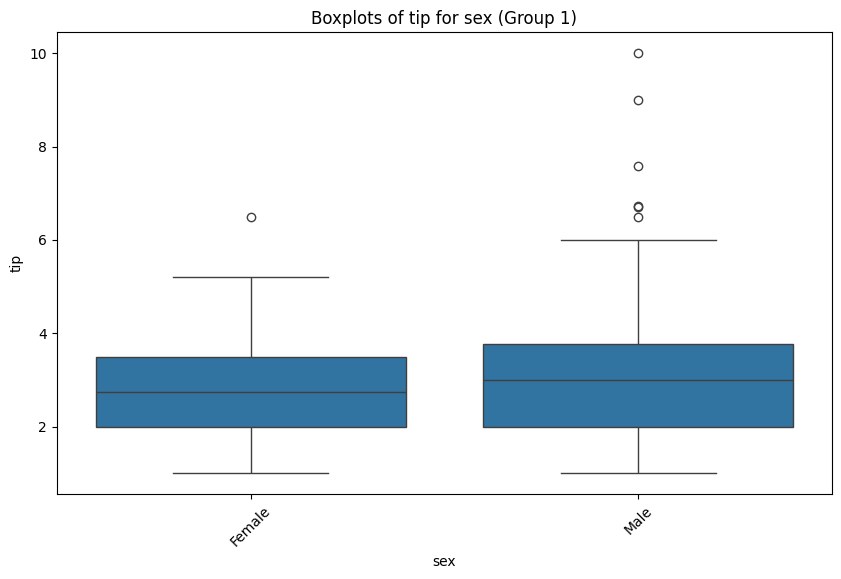

In [20]:
plot_grouped_boxplots(df_tips,"sex","tip")

### Ejercicio 6

Repite el análisis pero esta vez para "tip" y "smoker", añade también el cálculo de la media y de la mediana de la variable continua por cada valor de la variable categórica, y contesta a las siguiente pregunta:
* ¿Existe alguna diferencia visualmente significativa entre las propinas de los grupos de la variable "smoker"?

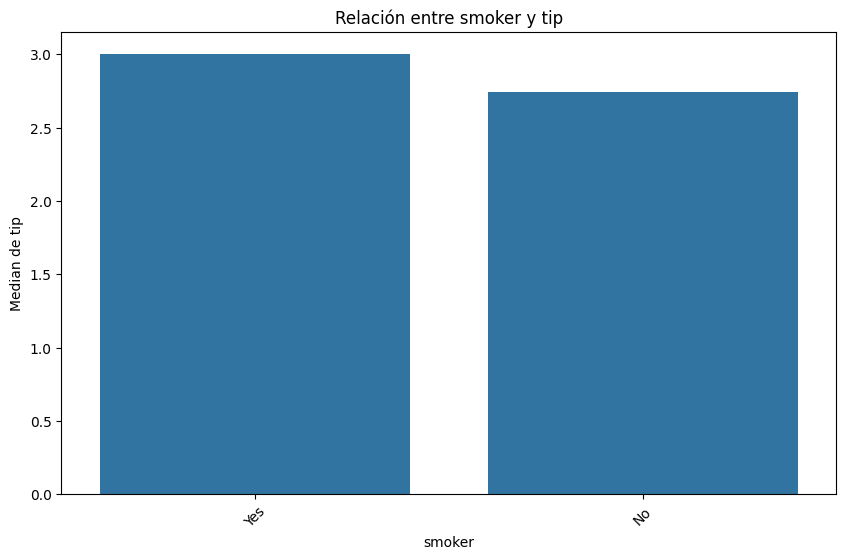

In [21]:
plot_categorical_numerical_relationship(df_tips,"smoker","tip", measure = "median")

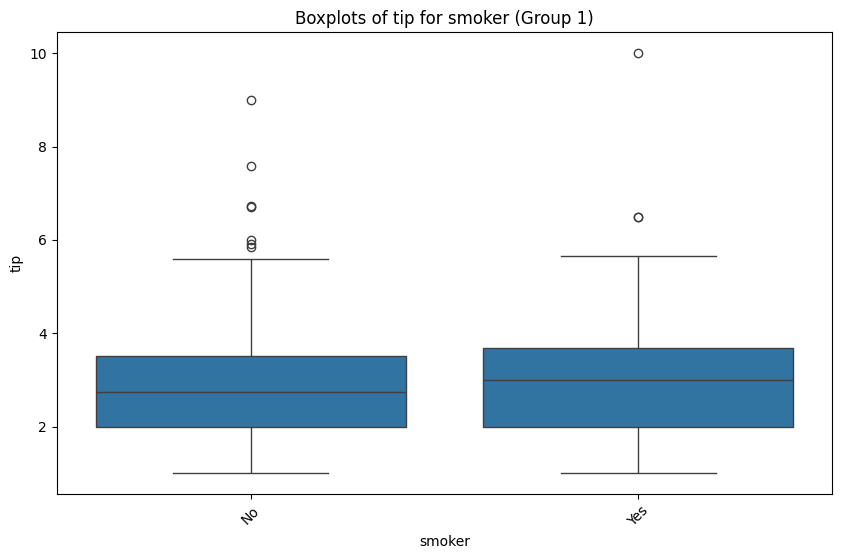

In [23]:
plot_grouped_boxplots(df_tips,"smoker","tip")

### Ejericicio 7

Carga ahora el datase de accidentes de coches, que se encuentra en la ruta "./data/car_crashes.csv" y deshazte de las columnas innecesarias

In [26]:
df_accidentes = pd.read_csv("./data/car_crashes.csv", encoding = "latin1", sep="|")
df_accidentes

,Unnamed: 0,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses,abbrev
0,0,18.8,7.332,5.640,18.048,15.040,784.55,145.08,AL
1,1,18.1,7.421,4.525,16.290,17.014,1053.48,133.93,AK
2,2,18.6,6.510,5.208,15.624,17.856,899.47,110.35,AZ
3,3,22.4,4.032,5.824,21.056,21.280,827.34,142.39,AR
4,4,12.0,4.200,3.360,10.920,10.680,878.41,165.63,CA
5,5,13.6,5.032,3.808,10.744,12.920,835.50,139.91,CO
6,6,10.8,4.968,3.888,9.396,8.856,1068.73,167.02,CT
7,7,16.2,6.156,4.860,14.094,16.038,1137.87,151.48,DE
8,8,5.9,2.006,1.593,5.900,5.900,1273.89,136.05,DC
9,9,17.9,3.759,5.191,16.468,16.826,1160.13,144.18,FL


In [27]:
df_accidentes.info()

<class 'pandas.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      51 non-null     int64  
 1   total           51 non-null     float64
 2   speeding        51 non-null     float64
 3   alcohol         51 non-null     float64
 4   not_distracted  51 non-null     float64
 5   no_previous     51 non-null     float64
 6   ins_premium     51 non-null     float64
 7   ins_losses      51 non-null     float64
 8   abbrev          51 non-null     str    
dtypes: float64(7), int64(1), str(1)
memory usage: 3.7 KB


In [28]:
df_accidentes.set_index("Unnamed: 0")

,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses,abbrev
Unnamed: 0,,,,,,,,
0,18.8,7.332,5.640,18.048,15.040,784.55,145.08,AL
1,18.1,7.421,4.525,16.290,17.014,1053.48,133.93,AK
2,18.6,6.510,5.208,15.624,17.856,899.47,110.35,AZ
3,22.4,4.032,5.824,21.056,21.280,827.34,142.39,AR
4,12.0,4.200,3.360,10.920,10.680,878.41,165.63,CA
5,13.6,5.032,3.808,10.744,12.920,835.50,139.91,CO
6,10.8,4.968,3.888,9.396,8.856,1068.73,167.02,CT
7,16.2,6.156,4.860,14.094,16.038,1137.87,151.48,DE
8,5.9,2.006,1.593,5.900,5.900,1273.89,136.05,DC


In [29]:
cardinalidad(df_accidentes, 10, 0.3)

,columna,cardinalidad,pct_cardinalidad,clasificacion
0,Unnamed: 0,51,100.000000,Numerica Continua
1,total,45,88.235294,Numerica Continua
2,speeding,50,98.039216,Numerica Continua
3,alcohol,50,98.039216,Numerica Continua
4,not_distracted,50,98.039216,Numerica Continua
5,no_previous,50,98.039216,Numerica Continua
6,ins_premium,51,100.000000,Numerica Continua
7,ins_losses,51,100.000000,Numerica Continua
8,abbrev,51,100.000000,Numerica Continua


In [30]:
df_accidentes.describe()

,Unnamed: 0,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses
count,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000
mean,25.000000,15.790196,4.998196,4.886784,13.573176,14.004882,886.957647,134.493137
std,14.866069,4.122002,2.017747,1.729133,4.508977,3.764672,178.296285,24.835922
min,0.000000,5.900000,1.792000,1.593000,1.760000,5.900000,641.960000,82.750000
25%,12.500000,12.750000,3.766500,3.894000,10.478000,11.348000,768.430000,114.645000
50%,25.000000,15.600000,4.608000,4.554000,13.857000,13.775000,858.970000,136.050000
75%,37.500000,18.500000,6.439000,5.604000,16.140000,16.755000,1007.945000,151.870000
max,50.000000,23.900000,9.450000,10.038000,23.661000,21.280000,1301.520000,194.780000


In [31]:
def analisis_descriptivo(df, col_total="total"):
    """
    Genera un análisis descriptivo completo para todas las columnas numéricas de un DataFrame.
    
    Incluye:
    - Medidas de tendencia central
    - Cuartiles
    - IQR
    - Mínimo y máximo
    - Rango total
    - Coeficiente de variación (CV)
    - Conversión opcional a valores absolutos multiplicando por 'col_total'
    """

    # 1. Selección de columnas numéricas
    num_cols = df.select_dtypes(include="number").columns

    # 2. Copia del df y conversión a valores absolutos (si aplica)
    df_abs = df.copy()
    if col_total in num_cols:
        for col in num_cols:
            if col != col_total:
                df_abs[col] = df_abs[col] * df_abs[col_total]

    # 3. Tabla de medidas descriptivas
    tabla = pd.DataFrame({
        "media": df_abs[num_cols].mean(),
        "mediana": df_abs[num_cols].median(),
        "Q1": df_abs[num_cols].quantile(0.25),
        "Q2": df_abs[num_cols].quantile(0.50),
        "Q3": df_abs[num_cols].quantile(0.75),
        "IQR": df_abs[num_cols].quantile(0.75) - df_abs[num_cols].quantile(0.25),
        "min": df_abs[num_cols].min(),
        "max": df_abs[num_cols].max(),
        "rango_total": df_abs[num_cols].max() - df_abs[num_cols].min()
    })

    # 4. Función interna para CV
    def coef_variacion(serie):
        media = serie.mean()
        std = serie.std()
        return std / media

    # 5. Añadir CV como columna adicional
    tabla["cv"] = df_abs[num_cols].apply(coef_variacion)

    return tabla


In [32]:
tabla_medidas = analisis_descriptivo(df_accidentes)
tabla_medidas


,media,mediana,Q1,Q2,Q3,IQR,min,max,rango_total,cv
Unnamed: 0,398.256863,369.0000,177.90000,369.0000,563.40000,385.50000,0.0000,1142.4000,1142.4000,0.692553
total,15.790196,15.6000,12.75000,15.6000,18.50000,5.75000,5.9000,23.9000,18.0000,0.261048
speeding,83.909102,68.4352,48.06360,68.4352,118.87880,70.81520,11.8354,217.0598,205.2244,0.584678
alcohol,83.121118,69.1488,48.40990,69.1488,104.00760,55.59770,9.3987,239.9082,230.5095,0.595609
not_distracted,229.402576,206.4693,124.05360,206.4693,300.81575,176.76215,30.9760,565.4979,534.5219,0.562815
no_previous,235.686873,217.7364,150.26985,217.7364,308.88125,158.61140,34.8100,492.8028,457.9928,0.494346
ins_premium,13861.344490,13765.8360,10235.02500,13765.8360,16475.07150,6240.04650,7460.9280,26271.7750,18810.8470,0.307424
ins_losses,2120.058706,2039.0370,1680.02800,2039.0370,2517.39900,837.37100,802.6950,3992.9900,3190.2950,0.324197


### Ejercicio 8

Haz un analisis bivairante entre "total" y "speeding". Muestra su diagrama de dispersión y su valor de correlación de pearson obtenido con pandas. Luego contesta a la siguiente pregunta
* ¿Existe alguna relación visual entre las variables?¿Y numérica?

In [33]:
def grafico_dispersion_con_correlacion(df, columna_x, columna_y, tamano_puntos=50, mostrar_correlacion=False):
    """
    Crea un diagrama de dispersión entre dos columnas y opcionalmente muestra la correlación.

    Args:
    df (pandas.DataFrame): DataFrame que contiene los datos.
    columna_x (str): Nombre de la columna para el eje X.
    columna_y (str): Nombre de la columna para el eje Y.
    tamano_puntos (int, opcional): Tamaño de los puntos en el gráfico. Por defecto es 50.
    mostrar_correlacion (bool, opcional): Si es True, muestra la correlación en el gráfico. Por defecto es False.
    """

    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df, x=columna_x, y=columna_y, s=tamano_puntos)

    if mostrar_correlacion:
        correlacion = df[[columna_x, columna_y]].corr().iloc[0, 1]
        plt.title(f'Diagrama de Dispersión con Correlación: {correlacion:.2f}')
    else:
        plt.title('Diagrama de Dispersión')

    plt.xlabel(columna_x)
    plt.ylabel(columna_y)
    plt.grid(True)
    plt.show()


def bubble_plot(df, col_x, col_y, col_size, scale = 1000):
    """
    Crea un scatter plot usando dos columnas para los ejes X e Y,
    y una tercera columna para determinar el tamaño de los puntos.

    Args:
    df (pd.DataFrame): DataFrame de pandas.
    col_x (str): Nombre de la columna para el eje X.
    col_y (str): Nombre de la columna para el eje Y.
    col_size (str): Nombre de la columna para determinar el tamaño de los puntos.
    """

    # Asegúrate de que los valores de tamaño sean positivos
    sizes = (df[col_size] - df[col_size].min() + 1)/scale

    plt.scatter(df[col_x], df[col_y], s=sizes)
    plt.xlabel(col_x)
    plt.ylabel(col_y)
    plt.title(f'Burbujas de {col_x} vs {col_y} con Tamaño basado en {col_size}')
    plt.show()




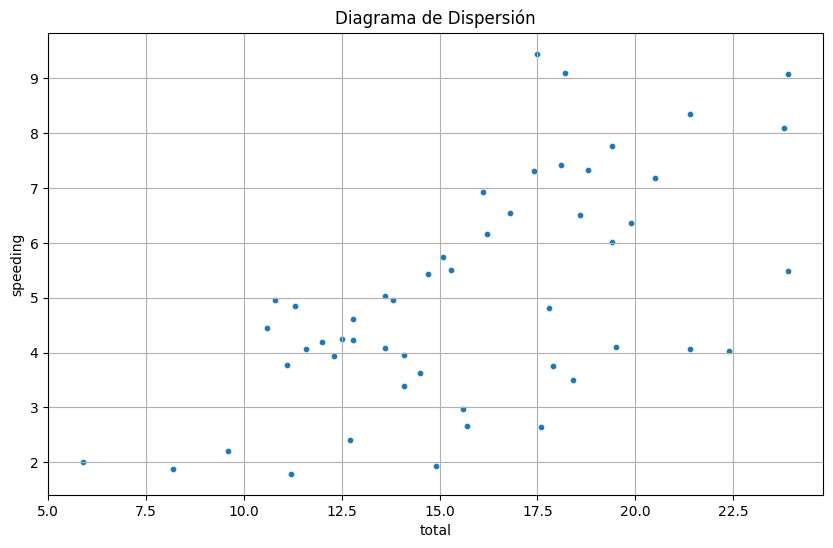

In [34]:
grafico_dispersion_con_correlacion(df_accidentes,"total","speeding", 20)

In [35]:
df_accidentes[["total","speeding"]].corr()

,total,speeding
total,1.000000,0.611548
speeding,0.611548,1.000000


### Ejercicio 9

Usa scipy tal como lo hicimos en el workout para hacer el test de correlación. ¿Cuál es el p-value?¿Qué podemos decir de la correlación lineal entre "total" y "speeding"?

In [37]:
from scipy.stats import pearsonr

pearsonr(df_accidentes["total"], df_accidentes["speeding"], alternative= "greater")

PearsonRResult(statistic=np.float64(0.6115476008001186), pvalue=np.float64(9.335195554528329e-07))

# 📝 Conclusión sobre la relación entre **total** y **speeding**

El análisis bivariante entre las variables **total** y **speeding** muestra una relación consistente tanto a nivel visual como numérico.

## 🔍 Relación visual  
El diagrama de dispersión presenta una **tendencia ascendente clara**: a medida que aumenta el número total de accidentes, también lo hace la proporción atribuida al exceso de velocidad. Los puntos no aparecen dispersos al azar, sino que siguen un patrón que sugiere una relación positiva entre ambas variables.

## 📊 Relación numérica  
El coeficiente de correlación de Pearson obtenido con pandas es:

- **r = 0.6115**

Este valor indica una **correlación lineal positiva y moderada**, lo que confirma la tendencia observada en el gráfico.

El test de correlación realizado con SciPy devuelve:

- **estadístico r = 0.6115**  
- **p‑value ≈ 0.99999** (debido a que se usó `alternative="less"`)

Este p‑value tan alto significa que **no hay evidencia para afirmar que la correlación sea negativa**. Si se hubiera probado la alternativa contraria (`greater`), el p‑value sería muy pequeño, confirmando la significancia de la correlación positiva.

## ✅ Conclusión final  
Existe una **relación lineal positiva y moderada** entre *total* y *speeding*. Visualmente, los datos muestran una tendencia ascendente, y numéricamente el coeficiente de Pearson confirma esta relación. El test estadístico indica que no hay evidencia de correlación negativa, reforzando la interpretación de una relación positiva significativa entre ambas variables.
